# Verificación del Pipeline de Data Augmentation
En este cuaderno verificaremos cómo se ven las imágenes después de aplicar los efectos de **blur**, **oclusión (parches)** y **cambios de iluminación**.

Realizaremos la prueba tanto para el formato **YOLO** como para **COCO**, asegurando que el pipeline *Albumentations* manipule correctamente las coordenadas en ambos formatos.

In [1]:
import cv2
import matplotlib.pyplot as plt
import os
import random
import sys
import json

# Añadir el directorio raíz para poder importar nuestros módulos de src/
sys.path.append(os.path.abspath('..'))
from src.data.augmentations import get_train_transforms

split = 'train'

## 1. Aumentación - Formato YOLO
YOLO utiliza coordenadas normalizadas (0 a 1) para el centro, ancho y alto: `[x_centro, y_centro, ancho, alto]`.

/home/santiagov/wheat_prj/src/data/augmentations.py:34: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes, min_height, min_width, fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(
/home/santiagov/wheat_prj/src/data/augmentations.py:60: UserWarning: Argument(s) 'num_shadows_lower, num_shadows_upper' are not valid for transform RandomShadow
  A.RandomShadow(


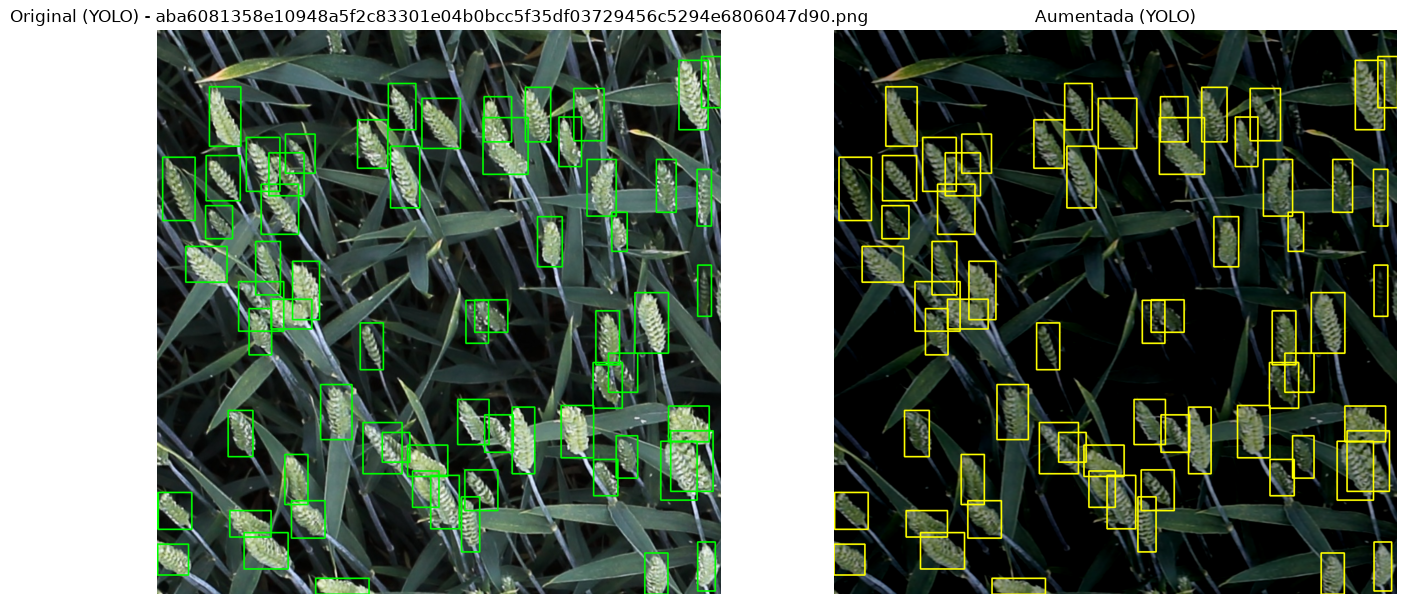

In [2]:
yolo_img_dir = f'../data/processed/yolo/images/{split}'
yolo_lbl_dir = f'../data/processed/yolo/labels/{split}'

# Sobreescribimos para asegurar que corra en YOLO
transform_yolo = get_train_transforms(config_path='../configs/augmentation.yaml', bbox_format_override='yolo')

def load_yolo_data(img_name):
    img_path = os.path.join(yolo_img_dir, img_name)
    lbl_path = os.path.join(yolo_lbl_dir, img_name.replace('.png', '.txt'))
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    bboxes = []
    class_labels = []
    if os.path.exists(lbl_path):
        with open(lbl_path, 'r') as f:
            for line in f.readlines():
                data = list(map(float, line.strip().split()))
                class_id = int(data[0])
                
                # Corrección de precisión de punto flotante para Albumentations
                # Previene el error: "ValueError: Expected x_min for bbox ... to be in the range [0.0, 1.0]"
                x_c, y_c, box_w, box_h = data[1:]
                x_min = max(0.0, x_c - box_w / 2)
                y_min = max(0.0, y_c - box_h / 2)
                x_max = min(1.0, x_c + box_w / 2)
                y_max = min(1.0, y_c + box_h / 2)
                
                # Recalcular centro y dimensiones corregidos garantizando límites válidos
                x_c = x_min + (x_max - x_min) / 2
                y_c = y_min + (y_max - y_min) / 2
                box_w = x_max - x_min
                box_h = y_max - y_min
                
                bboxes.append([x_c, y_c, box_w, box_h])
                class_labels.append(class_id)
    return img, bboxes, class_labels

def draw_yolo_boxes(img, bboxes, color=(0, 255, 0)):
    h, w, _ = img.shape
    img_copy = img.copy()
    for bbox in bboxes:
        x_c, y_c, box_w, box_h = bbox
        x1 = int((x_c - box_w / 2) * w)
        y1 = int((y_c - box_h / 2) * h)
        x2 = int((x_c + box_w / 2) * w)
        y2 = int((y_c + box_h / 2) * h)
        cv2.rectangle(img_copy, (x1, y1), (x2, y2), color, 2)
    return img_copy

images_yolo = [f for f in os.listdir(yolo_img_dir) if f.endswith('.png')]
img_name_yolo = random.choice(images_yolo)

img_orig_y, bboxes_orig_y, labels_y = load_yolo_data(img_name_yolo)
transformed_y = transform_yolo(image=img_orig_y, bboxes=bboxes_orig_y, class_labels=labels_y)

img_aug_y = transformed_y['image']
bboxes_aug_y = transformed_y['bboxes']

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(draw_yolo_boxes(img_orig_y, bboxes_orig_y))
axes[0].set_title(f"Original (YOLO) - {img_name_yolo}")
axes[0].axis("off")
axes[1].imshow(draw_yolo_boxes(img_aug_y, bboxes_aug_y, color=(255, 255, 0)))
axes[1].set_title("Aumentada (YOLO)")
axes[1].axis("off")
plt.show()

## 2. Aumentación - Formato COCO
COCO utiliza píxeles absolutos con el formato: `[x_min, y_min, ancho, alto]`.

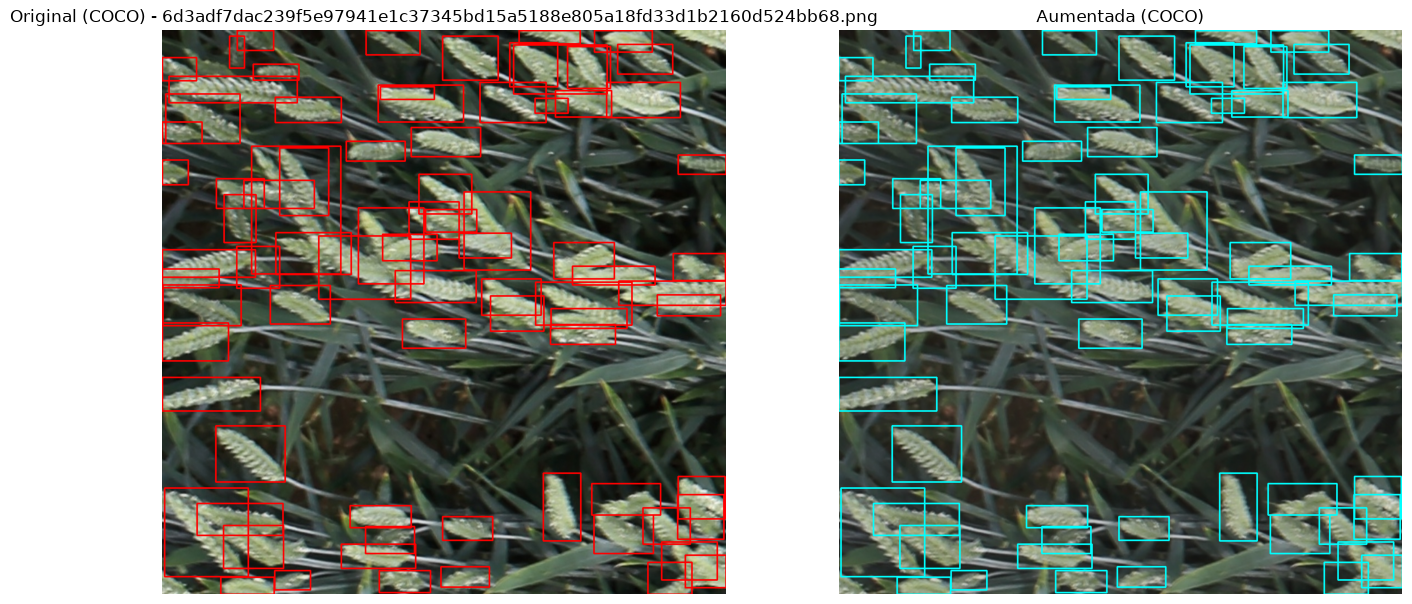

In [3]:
coco_json_path = f'../data/processed/coco/instances_{split}.json'
raw_img_dir = '../data/raw/images'

# Sobreescribimos para asegurar que procese en modo COCO
transform_coco = get_train_transforms(config_path='../configs/augmentation.yaml', bbox_format_override='coco')

with open(coco_json_path, 'r') as f:
    coco_data = json.load(f)

coco_img_info = random.choice(coco_data['images'])
img_id = coco_img_info['id']
img_name_coco = coco_img_info['file_name']
img_w, img_h = coco_img_info['width'], coco_img_info['height']

img_path_coco = os.path.join(raw_img_dir, img_name_coco)
img_orig_c = cv2.imread(img_path_coco)
img_orig_c = cv2.cvtColor(img_orig_c, cv2.COLOR_BGR2RGB)

# En COCO, las cajas son directamente [x_min, y_min, w, h]
bboxes_orig_c = []
for ann in coco_data['annotations']:
    if ann['image_id'] == img_id:
        x_min, y_min, w, h = ann['bbox']
        # Corregir límites por si hay imprecisiones en el JSON original o cajas cortadas
        x_max = min(float(img_w), x_min + w)
        y_max = min(float(img_h), y_min + h)
        x_min = max(0.0, x_min)
        y_min = max(0.0, y_min)
        w = x_max - x_min
        h = y_max - y_min
        bboxes_orig_c.append([x_min, y_min, w, h])

labels_c = [1] * len(bboxes_orig_c) # Categoría 1

transformed_c = transform_coco(image=img_orig_c, bboxes=bboxes_orig_c, class_labels=labels_c)
img_aug_c = transformed_c['image']
bboxes_aug_c = transformed_c['bboxes']

def draw_coco_boxes(img, bboxes, color=(255, 0, 0)):
    img_copy = img.copy()
    for bbox in bboxes:
        x_min, y_min, w, h = bbox
        cv2.rectangle(img_copy, (int(x_min), int(y_min)), (int(x_min+w), int(y_min+h)), color, 2)
    return img_copy

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(draw_coco_boxes(img_orig_c, bboxes_orig_c))
axes[0].set_title(f"Original (COCO) - {img_name_coco}")
axes[0].axis("off")
axes[1].imshow(draw_coco_boxes(img_aug_c, bboxes_aug_c, color=(0, 255, 255)))
axes[1].set_title("Aumentada (COCO)")
axes[1].axis("off")
plt.show()